# Hari 2 — Business Understanding: Project Charter

**Tujuan hari ini:**
1. Memahami perbedaan *business objective*, *data mining goal*, dan *success criteria*
2. Mengubah jawaban refleksi Hari 1 menjadi **Project Charter** yang konkret
3. Menetapkan **baseline** sederhana sebagai pembanding — supaya nanti di fase Modeling kamu tahu "model bagus" itu tolok ukurnya apa

Ini beda dari Day 2 versi generik di roadmap (yang pakai studi kasus churn hipotetis) — kita langsung terapkan ke proyek COVID-19 Indonesia kamu, karena kamu sudah punya arah yang jelas dari Hari 1.

## Konsep: 3 Lapis dalam Business Understanding

| Lapisan | Pertanyaan Kunci | Contoh |
|---|---|---|
| **Business Objective** | Masalah dunia nyata apa yang ingin diselesaikan? | "Masyarakat sulit tahu apakah kasus COVID di daerahnya akan naik minggu depan" |
| **Data Mining Goal** | Terjemahan objective di atas ke tugas teknis | "Memprediksi jumlah kasus baru mingguan dari data historis" |
| **Success Criteria** | Kapan proyek ini dianggap berhasil? | Business: orang awam paham tren dalam sekali lihat. Technical: prediksi lebih akurat dari baseline naif |

Kesalahan paling umum pemula: langsung lompat ke "data mining goal" (mau bikin model) tanpa menjawab business objective dulu. Itu sebabnya CRISP-DM menaruh fase ini paling awal.

## Refleksi Hari 1 Kamu

> 1. Business question: **Bisakah kita memprediksi tren kenaikan kasus mingguan?**
> 2. Target pengguna: **masyarakat umum**
> 3. Data yang masih kurang: **data vaksinasi**

Tiga jawaban ini sudah cukup jadi fondasi. Sekarang kita bentuk jadi Project Charter formal di bawah.

## Project Charter — Prediksi Tren Kasus COVID-19 Mingguan

**Business Objective**
Membantu masyarakat umum mendapatkan gambaran sederhana apakah kasus COVID-19 di suatu wilayah cenderung **naik, turun, atau stabil** pada minggu berikutnya, tanpa perlu membaca data mentah.

**Data Mining Goal**
Membangun model *time-series forecasting* yang memprediksi **jumlah kasus baru mingguan** untuk periode berikutnya, berdasarkan pola kasus historis.

**Scope (asumsi awal — boleh kamu ubah di Refleksi bagian bawah):**
- Level agregasi: **nasional** dulu (semua provinsi digabung), supaya polanya jelas dan datanya cukup padat. Prediksi per-provinsi bisa jadi pengembangan lanjutan.
- Horizon prediksi: **1 minggu ke depan**, berdasarkan data beberapa minggu sebelumnya.

**Target Pengguna**
Masyarakat umum — artinya output model **harus mudah dibaca** (misal: label "↑ Naik" / "↓ Turun" / "→ Stabil", bukan cuma angka mentah).

**Keterbatasan yang Sudah Diketahui**
- Data vaksinasi tidak tersedia di dataset ini, padahal secara logis vaksinasi memengaruhi laju penyebaran. Ini dicatat sebagai **limitation**, bukan blocker — model tetap bisa dibangun hanya dari pola historis kasus (disebut *univariate time-series*), tapi akurasinya punya batas wajar.
- Data pelaporan kasus COVID sering punya *noise* (keterlambatan lapor, revisi angka) — perlu diwaspadai saat EDA nanti.

## Step 1 — Muat Ulang Data

Lanjutan dari notebook Hari 1. Pastikan file CSV ada di direktori yang sama, atau upload ulang jika perlu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILENAME = "covid_19_indonesia_time_series_all.csv"
df = pd.read_csv(FILENAME)
df["Date"] = pd.to_datetime(df["Date"])
print(f"Dataset dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
print(list(df.columns))

Dataset dimuat: 31822 baris, 38 kolom
['Date', 'Location ISO Code', 'Location', 'New Cases', 'New Deaths', 'New Recovered', 'New Active Cases', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Total Active Cases', 'Location Level', 'City or Regency', 'Province', 'Country', 'Continent', 'Island', 'Time Zone', 'Special Status', 'Total Regencies', 'Total Cities', 'Total Districts', 'Total Urban Villages', 'Total Rural Villages', 'Area (km2)', 'Population', 'Population Density', 'Longitude', 'Latitude', 'New Cases per Million', 'Total Cases per Million', 'New Deaths per Million', 'Total Deaths per Million', 'Total Deaths per 100rb', 'Case Fatality Rate', 'Case Recovered Rate', 'Growth Factor of New Cases', 'Growth Factor of New Deaths']


## Step 2 — Pahami Skala Masalah: Tren Kasus Mingguan Nasional

Sebelum menetapkan target akurasi, kita perlu tahu dulu **seberapa besar dan seberapa fluktuatif** angka yang mau diprediksi. Kode di bawah mencoba mengambil baris agregat nasional (biasanya `Location` = `"Indonesia"`); kalau tidak ada, dijumlahkan manual dari semua provinsi.

count       133.000000
mean      48158.225564
std       75601.560896
min           6.000000
25%        5261.000000
50%       24932.000000
75%       42024.000000
max      389727.000000
Name: New Cases, dtype: float64


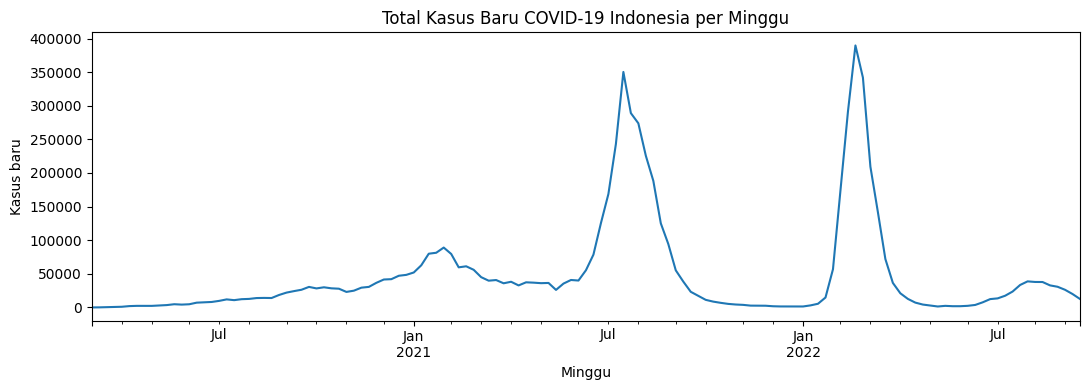

In [2]:
# Coba ambil baris agregat nasional langsung
if "Location" in df.columns and "Indonesia" in df["Location"].unique():
    national = df[df["Location"] == "Indonesia"][["Date", "New Cases"]].copy()
else:
    # fallback: jumlahkan semua wilayah per tanggal
    national = df.groupby("Date", as_index=False)["New Cases"].sum()

national = national.sort_values("Date").set_index("Date")

# Resample ke mingguan (jumlah kasus baru per minggu)
weekly = national["New Cases"].resample("W").sum()

print(weekly.describe())

plt.figure(figsize=(11, 4))
weekly.plot()
plt.title("Total Kasus Baru COVID-19 Indonesia per Minggu")
plt.ylabel("Kasus baru")
plt.xlabel("Minggu")
plt.tight_layout()
plt.show()

## Step 3 — Tetapkan Baseline (Naive Forecast)

Baseline paling sederhana dalam forecasting: **"prediksi minggu depan = angka minggu ini"**. Terdengar terlalu simpel, tapi ini justru penting — kalau model machine learning kamu nanti tidak bisa mengalahkan baseline ini, artinya modelnya belum berguna secara praktis.

Kita hitung MAE (Mean Absolute Error) dari baseline ini sebagai **angka yang harus dikalahkan** nanti di fase Modeling (Minggu 3).

In [3]:
# Baseline: prediksi minggu ini = nilai minggu lalu (shift 1)
naive_pred = weekly.shift(1)

# Buang baris pertama (tidak ada prediksi untuk minggu pertama)
valid = weekly.iloc[1:]
pred = naive_pred.iloc[1:]

mae_baseline = (valid - pred).abs().mean()
mape_baseline = ((valid - pred).abs() / valid.replace(0, np.nan)).mean() * 100

print(f"Baseline MAE  : {mae_baseline:,.0f} kasus/minggu")
print(f"Baseline MAPE : {mape_baseline:.1f}%")
print("\n>> Simpan dua angka ini. Nanti di Hari 15-21 (Modeling), model kamu HARUS mengalahkan angka ini.")

Baseline MAE  : 12,953 kasus/minggu
Baseline MAPE : 26.0%

>> Simpan dua angka ini. Nanti di Hari 15-21 (Modeling), model kamu HARUS mengalahkan angka ini.


## Menetapkan Success Criteria (Final)

Isi bagian **MAE baseline** dan **MAPE baseline** di bawah dengan angka hasil Step 3 di atas punyamu (angkanya akan beda tergantung rentang data yang kamu download):

**Business Success Criteria**
- Output prediksi bisa diringkas jadi label sederhana (↑ Naik / ↓ Turun / → Stabil) yang bisa dipahami tanpa latar belakang statistik

**Technical Success Criteria**
- Model prediksi mingguan harus punya MAE **lebih rendah** dari baseline naive (`≈ 13`)
- Target realistis: perbaikan minimal 15-20% dibanding baseline (bukan angka sempurna — di data pandemi yang sangat fluktuatif, itu wajar)

**Bukan Tujuan Proyek Ini (out of scope)**
- Prediksi per-kabupaten/kota (skala data terlalu kecil & noisy untuk pemula)
- Analisis kausal ("apa penyebab lonjakan kasus") — itu topik terpisah dari forecasting

## Risiko & Batasan Proyek

| Risiko | Dampak | Mitigasi |
|---|---|---|
| Tidak ada data vaksinasi | Model tidak menangkap efek vaksinasi terhadap penurunan kasus | Catat sebagai limitation di laporan akhir; opsional: cari dataset vaksinasi terpisah di Hari 27-28 kalau mau proyek lebih kaya |
| Data pelaporan tidak konsisten (lonjakan aneh karena keterlambatan lapor) | Model bisa "belajar" pola yang salah | Akan ditangani di Data Preparation (Minggu 2) — smoothing / deteksi anomali |
| Data berhenti di suatu tanggal tertentu (dataset tidak update real-time) | Model hanya relevan untuk periode historis, bukan kondisi terkini | Jelaskan di dokumentasi akhir bahwa ini proyek pembelajaran, bukan sistem produksi |

## Project Plan Ringkas (Disesuaikan untuk Proyek Ini)

| Fase CRISP-DM | Hari | Fokus untuk proyek COVID-19 ini |
|---|---|---|
| Business Understanding | 1-2 (selesai) | Project charter, baseline naive |
| Data Understanding | 4-7 | EDA time-series: tren, musiman, anomali |
| Data Preparation | 8-14 | Handling missing/outlier, buat fitur lag & rolling average |
| Modeling | 15-21 | Coba regresi/tree-based dulu untuk latihan (dataset Titanic), baru terapkan konsep time-series ke data COVID |
| Evaluation | 22-23 | Bandingkan MAE model vs baseline naive |
| Deployment | 24-30 | Streamlit app: input tanggal → tampilkan prediksi + label tren |

Catatan: latihan classification (Titanic dkk) di Minggu 3 tetap jalan sesuai roadmap supaya kamu paham fundamental ML secara luas — modelnya nanti kamu terapkan ke kasus forecasting COVID-19 ini sebagai proyek utama.

## Refleksi & Keputusan Kamu

Isi/ubah bagian ini sesuai preferensimu — ini scope resmi proyekmu selama 30 hari ke depan:

> 1. Level agregasi: nasional / per-provinsi (pilih satu) → nasional
> 2. Horizon prediksi: 1 minggu / 2 minggu / lainnya → 1 minggu
> 3. Apakah kamu mau cari data vaksinasi tambahan nanti (opsional)? → ya

---
### Selanjutnya: Hari 3 — Memilih Dataset & Framing Masalah Lanjutan
Karena kamu sudah punya proyek utama (COVID-19), Hari 3 versi kamu bisa dipakai untuk: eksplorasi 2-3 dataset **pendukung** (misal data vaksinasi atau mobilitas) sebagai calon pengayaan proyek nanti — sifatnya opsional, boleh dilewati langsung ke Hari 4 (Data Understanding) kalau mau fokus dulu ke data yang sudah ada.